# Mix-Only Model — Validation Evaluation
Runs the fine-tuned checkpoint in **mix-only mode** (same as competition inference) on the val split and prints a full classification report. Use this to judge submission quality before using a Kaggle slot.

In [1]:
import sys
from pathlib import Path

# ── Point this to your project root ──────────────────────────────────────────
PROJECT_ROOT = Path(".").resolve()  # run notebook from project root, or set explicitly
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

Project root: /home/saber/IITM/DL-GenAI-Project/notebooks


In [2]:
import pickle
import numpy as np
import pandas as pd
import torch
import yaml
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ensure project root points to folder containing `src/`
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
	PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
	sys.path.insert(0, str(PROJECT_ROOT))

from src.models.messy_mashup_model import build_model
from src.utils.audio_utils import fix_length, normalise_mel

print(f"Imports OK (PROJECT_ROOT={PROJECT_ROOT})")

Imports OK (PROJECT_ROOT=/home/saber/IITM/DL-GenAI-Project)


In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
def load_cfg(path):
    with open(path) as f:
        return yaml.safe_load(f)

base_cfg  = load_cfg(PROJECT_ROOT / "configs/base_config.yaml")
model_cfg = load_cfg(PROJECT_ROOT / "configs/model_config.yaml")

paths      = base_cfg["paths"]
audio      = base_cfg["audio"]
mel_path   = PROJECT_ROOT / paths["mel_path"]
splits_path = PROJECT_ROOT / paths["splits_path"]

# ── Toggle this to compare original vs fine-tuned checkpoint ─────────────────
CHECKPOINT = PROJECT_ROOT / "checkpoints/best_multibranch_model.pth"
# CHECKPOINT = PROJECT_ROOT / "checkpoints/best_multibranch_model.pth"  # original

LE_PATH    = PROJECT_ROOT / "checkpoints/label_encoder.pkl"
VAL_CSV    = splits_path / "val.csv"
BATCH_SIZE = 32
NUM_WORKERS = 4

print(f"Checkpoint : {CHECKPOINT}")
print(f"Val CSV    : {VAL_CSV}")
print(f"Mel path   : {mel_path}")

Checkpoint : /home/saber/IITM/DL-GenAI-Project/checkpoints/best_multibranch_model.pth
Val CSV    : /home/saber/IITM/DL-GenAI-Project/data/splits/val.csv
Mel path   : /home/saber/IITM/DL-GenAI-Project/data/processed/mel_spectrograms


In [4]:
# ── Mix-Only Dataset (mirrors competition inference exactly) ──────────────────
class MixOnlyDataset(Dataset):
    def __init__(self, csv_file, mel_path, label2idx, target_frames=1300):
        self.mel_path = Path(mel_path)
        self.target_frames = target_frames
        self.df = pd.read_csv(csv_file)
        self.label2idx = label2idx

    def __len__(self):
        return len(self.df)

    def _load_mix_mel(self, file_base):
        path = self.mel_path / f"{file_base}__mix.npy"
        if not path.exists():
            parts = file_base.split("__", 1)
            if len(parts) == 2:
                genre, track = parts
                for candidate in [f"{genre}_{track}_mix.wav.npy", f"{genre}_{track}_mix.npy"]:
                    p = self.mel_path / candidate
                    if p.exists():
                        path = p
                        break
        if not path.exists():
            print(f"  [WARN] mix mel not found: {file_base}")
            return torch.zeros(1, 128, self.target_frames)
        mel = np.load(path).astype(np.float32)
        mel = fix_length(mel, self.target_frames)
        mel = normalise_mel(mel)
        return torch.from_numpy(mel).float().unsqueeze(0)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        mel = self._load_mix_mel(row["file_base"])
        label = self.label2idx[row["label"]]
        return {"bass": mel, "drums": mel, "other": mel, "vocals": mel, "mix": mel, "label": label}

print("Dataset class defined")

Dataset class defined


In [5]:
# ── Load model & label encoder ────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

with open(LE_PATH, "rb") as f:
    le = pickle.load(f)
label2idx = {g: i for i, g in enumerate(le.classes_)}
idx2label = {i: g for g, i in label2idx.items()}
class_names = list(le.classes_)
print(f"Classes: {class_names}")

ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
model = build_model(num_classes=len(class_names), model_cfg=model_cfg["model"])
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(device)
model.eval()
print(f"Checkpoint loaded ✓  (epoch {ckpt.get('epoch', '?')})")

Device: cuda
Classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Checkpoint loaded ✓  (epoch 48)


In [6]:
# ── Run inference on val set ──────────────────────────────────────────────────
val_ds = MixOnlyDataset(VAL_CSV, mel_path, label2idx, target_frames=audio["target_frames"])
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f"Val samples: {len(val_ds)}")

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating"):
        labels = batch.pop("label")
        batch  = {k: v.to(device) for k, v in batch.items()}
        out    = model(batch)
        preds  = out["logits"].argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

print("Inference complete")

Val samples: 150


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

Inference complete


In [7]:
# ── Classification Report ─────────────────────────────────────────────────────
pred_names  = [idx2label[p] for p in all_preds]
label_names = [idx2label[l] for l in all_labels]

print(classification_report(label_names, pred_names, target_names=sorted(class_names)))

              precision    recall  f1-score   support

       blues       0.00      0.00      0.00        15
   classical       0.00      0.00      0.00        15
     country       0.00      0.00      0.00        15
       disco       0.00      0.00      0.00        15
      hiphop       0.88      1.00      0.94        15
        jazz       0.13      1.00      0.23        15
       metal       1.00      0.07      0.12        15
         pop       0.00      0.00      0.00        15
      reggae       1.00      0.13      0.24        15
        rock       0.00      0.00      0.00        15

    accuracy                           0.22       150
   macro avg       0.30      0.22      0.15       150
weighted avg       0.30      0.22      0.15       150



/home/saber/IITM/DL-GenAI-Project/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/saber/IITM/DL-GenAI-Project/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/saber/IITM/DL-GenAI-Project/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [8]:
# ── Genre distribution of predictions (sanity check) ─────────────────────────
pred_series = pd.Series(pred_names, name="predicted")
true_series = pd.Series(label_names, name="actual")

dist = pd.DataFrame({"actual": true_series.value_counts(), "predicted": pred_series.value_counts()}).fillna(0).astype(int)
print(dist.to_string())

           actual  predicted
blues          15         16
classical      15          0
country        15          0
disco          15          0
hiphop         15         17
jazz           15        114
metal          15          1
pop            15          0
reggae         15          2
rock           15          0


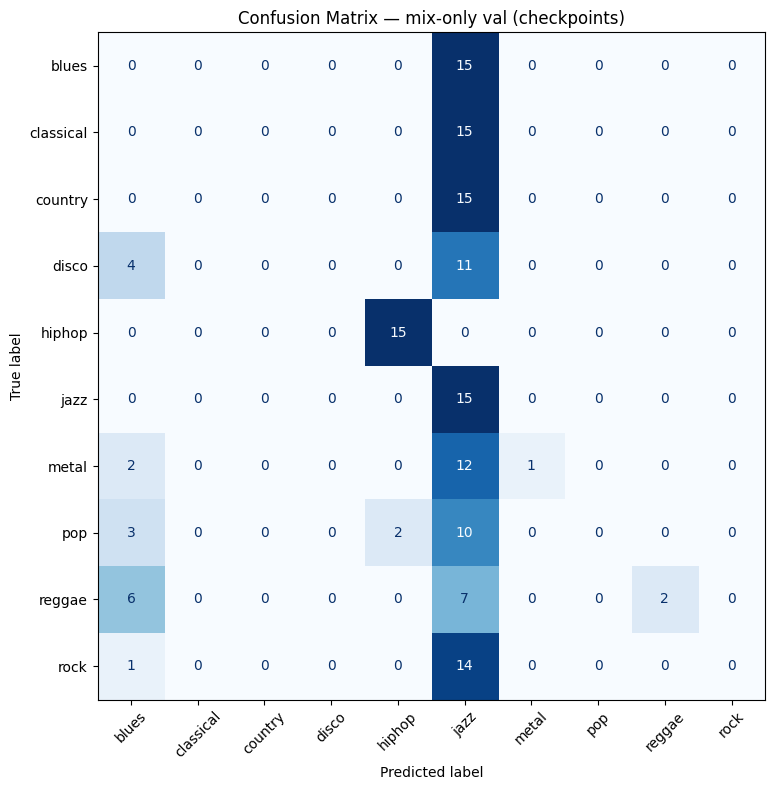

Saved → experiments/confusion_mix_val.png


: 

In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(label_names, pred_names, labels=sorted(class_names))
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(class_names))
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title(f"Confusion Matrix — mix-only val ({Path(CHECKPOINT).parent.name})")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments/confusion_mix_val.png", dpi=150)
plt.show()
print("Saved → experiments/confusion_mix_val.png")